In [ ]:

#  Improved HECANet — EEG + Telematics Fusion


# 1️⃣ Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import AdamW

# 2️⃣ Mount & Load Datasets
from google.colab import drive
drive.mount('/content/drive')

EEG_PATH = "/content/drive/MyDrive/mini2datasets/emotions.csv"
TELE_PATH = "/content/drive/MyDrive/mini2datasets/allcars.csv"

print("📂 Loading Datasets...")
emotions = pd.read_csv(EEG_PATH)
telematics = pd.read_csv(TELE_PATH)
print("EEG Shape:", emotions.shape, "| Telematics Shape:", telematics.shape)

# 3️⃣ EEG Preprocessing
label_col = None
for c in emotions.columns:
    if c.lower() in ['emotion','label','target','class','state']:
        label_col = c
        break

if label_col is None:
    label_col = emotions.columns[-1]
    print(f"⚠️ No label column detected — using last column: {label_col}")

le = LabelEncoder()
emotions[label_col] = le.fit_transform(emotions[label_col].astype(str))
print("✅ Emotion classes encoded:", list(le.classes_))

# Separate numeric EEG features
eeg_data = emotions.drop(columns=[label_col]).select_dtypes(include=[np.number])
if eeg_data.shape[1] == 0:
    raise ValueError("No numeric EEG columns found!")

# 4️⃣ Telematics Preprocessing
drop_cols = ['Timestamp','Time','Date','DriverID','VehicleType','CarID','TripID','TripStartTime']
telematics.drop(columns=[c for c in drop_cols if c in telematics.columns], inplace=True, errors='ignore')

# Drop non-numeric
non_numeric = telematics.select_dtypes(exclude=[np.number]).columns
if len(non_numeric) > 0:
    print("Dropping non-numeric telematics columns:", list(non_numeric))
    telematics.drop(columns=non_numeric, inplace=True)

# Clean NaN/Inf
telematics.replace([np.inf, -np.inf], np.nan, inplace=True)
telematics.fillna(telematics.mean(numeric_only=True), inplace=True)

# Outlier clipping (3σ rule)
num_cols = telematics.select_dtypes(include=[np.number]).columns
means, stds = telematics[num_cols].mean(), telematics[num_cols].std()
telematics[num_cols] = telematics[num_cols].clip(lower=means - 3*stds, upper=means + 3*stds, axis=1)

# Feature engineering
if 'Speed' in telematics.columns and 'Acceleration' in telematics.columns:
    telematics['speed_var'] = (telematics['Speed'] - telematics['Speed'].shift(1)).fillna(0)**2
    telematics['accel_mean'] = telematics['Acceleration'].rolling(window=3, min_periods=1).mean().fillna(method='bfill')

telematics = telematics.apply(pd.to_numeric, downcast='float')
print("✅ Telematics cleaned:", telematics.shape)

# 5️⃣ Aggregate Telematics to Match EEG
n_eeg = len(eeg_data)
n_tele = len(telematics)
agg_size = max(1, n_tele // n_eeg)
print(f"Aggregation size: {agg_size}")

scaler_tele = StandardScaler()
tele_scaled = scaler_tele.fit_transform(telematics)

tele_df = pd.DataFrame(tele_scaled)
tele_agg = tele_df.groupby(np.arange(len(tele_df)) // agg_size).mean().reset_index(drop=True)
if len(tele_agg) < n_eeg:
    tele_agg = pd.concat([tele_agg, tele_agg.iloc[[-1]].repeat(n_eeg - len(tele_agg), axis=0)], ignore_index=True)
tele_agg = tele_agg.iloc[:n_eeg]
print("✅ Aggregated telematics shape:", tele_agg.shape)

# 6️⃣ Fusion
scaler_eeg = StandardScaler()
eeg_scaled = scaler_eeg.fit_transform(eeg_data)
X_combined = np.hstack((eeg_scaled, tele_agg.values))
y = emotions[label_col].values[:n_eeg]
print("Combined Feature Shape:", X_combined.shape)

# 7️⃣ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)
X_train_r = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_r = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# 8️⃣ Class Balancing
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("⚖️ Class Weights:", class_weights)



Mounted at /content/drive
📂 Loading Datasets...
EEG Shape: (2132, 2549) | Telematics Shape: (7214695, 18)
✅ Emotion classes encoded: ['NEGATIVE', 'NEUTRAL', 'POSITIVE']
Dropping non-numeric telematics columns: ['timeStamp', 'accData']
✅ Telematics cleaned: (7214695, 16)
Aggregation size: 3384
✅ Aggregated telematics shape: (2132, 16)
Combined Feature Shape: (2132, 2564)
⚖️ Class Weights: {0: np.float64(1.0041224970553593), 1: np.float64(0.9918557300756253), 2: np.float64(1.0041224970553593)}


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 🧩 1️⃣ Combine EEG and Telematics
# ==========================================
# Assume you already have:
# X_eeg_scaled  → EEG features after scaling
# tele_agg      → Aggregated telematics features
# y             → Emotion labels

# Combine features
X_combined = np.hstack((eeg_scaled, tele_agg.values))
print("✅ Combined Feature Shape:", X_combined.shape)

# ==========================================
# ✂️ 2️⃣ Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)


X_train_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Train shape:", X_train_reshaped.shape)
print("Test shape:", X_test_reshaped.shape)



✅ Combined Feature Shape: (2132, 2564)
Train shape: (1705, 2564, 1)
Test shape: (427, 2564, 1)


Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 338s 6s/step - accuracy: 0.6150 - loss: 0.8179 - val_accuracy: 0.7471 - val_loss: 0.5911 - learning_rate: 0.0010
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 308s 6s/step - accuracy: 0.8318 - loss: 0.4586 - val_accuracy: 0.7096 - val_loss: 0.5867 - learning_rate: 0.0010
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 318s 6s/step - accuracy: 0.8856 - loss: 0.3150 - val_accuracy: 0.8571 - val_loss: 0.5220 - learning_rate: 0.0010
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 308s 6s/step - accuracy: 0.8532 - loss: 0.4280 - val_accuracy: 0.8689 - val_loss: 0.4821 - learning_rate: 0.0010
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 324s 6s/step - accuracy: 0.8978 - loss: 0.3053 - val_accuracy: 0.8946 - val_loss: 0.2957 - learning_rate: 0.0010
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 326s 6s/step - accuracy: 0.9085 - loss: 0.2525 - val_accuracy: 0.9133 - val_loss: 0.2467 - learning_rate: 0.0010
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 321s 6s/step - accuracy: 0.9079 - loss: 0.2601 - val_acc

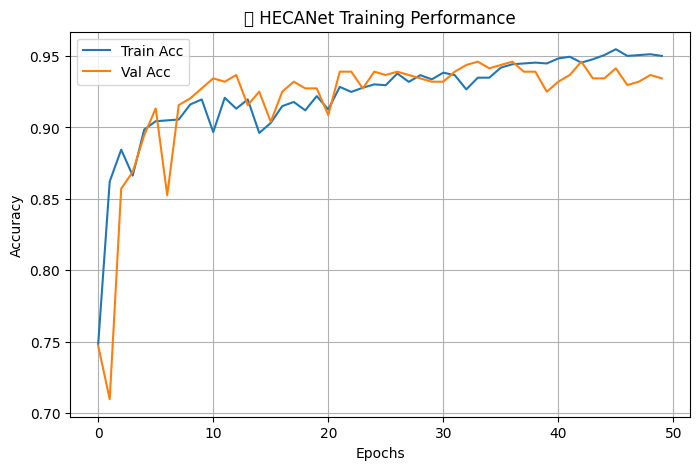

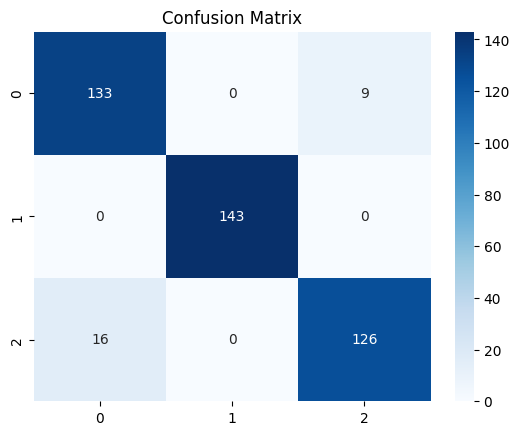

In [ ]:
# ==========================================
# Define Improved HECANet Model
# ==========================================
model = models.Sequential([
    layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    layers.BatchNormalization(),
    layers.Conv1D(128, kernel_size=3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.4),

    layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3),
    layers.LSTM(64, return_sequences=False),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(np.unique(y)), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# ⚙️ 5️⃣ Callbacks for Early Stopping
# ==========================================
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

# ==========================================
# 🚀 6️⃣ Train the Model
# ==========================================
history = model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_test_reshaped, y_test),
    epochs=50,
    batch_size=32,

    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 📈 7️⃣ Evaluate Model
# ==========================================
test_loss, test_acc = model.evaluate(X_test_reshaped, y_test)
print(f"\n✅ Test Accuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")

y_pred = np.argmax(model.predict(X_test_reshaped), axis=1)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ==========================================
# 📊 8️⃣ Visualization
# ==========================================
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('🧠 HECANet Training Performance')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 🔍 9️⃣ Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()
